# SENG404 Q4 — Within-Repo Agent Comparison & Specialization (AIDev)

**Question.** In repositories where multiple agents are used and a minimum PR threshold
is met, which agents achieve higher acceptance rates and faster merges? Do agents appear
to *specialize* within a repo (by task type, or by change size)?

**Design idea.** Restrict to repos where ≥2 agents appear with enough PRs each, so we
compare agents *within the same repo* — this holds repo culture / maintainer strictness /
domain fixed (the confound that a global comparison can't separate).

**How to use this notebook**
1. Point `DATA_DIR` at the AIDev parquet files (depth/curated set).
2. Run Section 3 (feasibility gate) **first** — it tells you if Q4 is answerable and at what threshold.
3. Sections 4–7 are the analysis; models in 5/7 need `statsmodels` and `lifelines`.

This is a scaffold: the joins and feasibility logic are ready to run; the model cells are
written to run but should be sanity-checked against your actual `N` from Section 3.


## 0. Config

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- EDIT THIS: folder containing the AIDev parquet files (depth/curated set) ---
DATA_DIR = Path("./aidev")

# The five agents in AIDev. Normalize variants you find in the `agent` column to these.
AGENTS = ["Claude Code", "Cursor", "Devin", "GitHub Copilot", "OpenAI Codex"]

# Feasibility thresholds: a repo "qualifies" if >= MIN_AGENTS agents each have >= k PRs.
K_GRID = [5, 10]          # report sensitivity across these
MIN_AGENTS_PER_REPO = 2

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


## 1. Load tables

Getting the files: install `datasets` / `huggingface_hub` and pull the parquet files from
`hao-li/AIDev`, or download them once and read locally. Use the **depth/curated** tables
(the enriched popular-repo set), not the 116K-repo breadth set — Q4 needs repos with real
review activity and multiple agents.

Tables we use: `pull_request`, `pr_commit_details`, `pr_commits`, `pr_task_type`, `repository`.


In [2]:
def load(name):
    p = DATA_DIR / f"{name}.parquet"
    df = pd.read_parquet(p)
    print(f"{name:18s} {df.shape}  cols={list(df.columns)[:8]}{'...' if df.shape[1] > 8 else ''}")
    return df

pr        = load("pull_request")       # or "all_pull_request"
commits   = load("pr_commits")         # one row per commit
cdetails  = load("pr_commit_details")  # one row PER FILE per commit
tasktype  = load("pr_task_type")       # LLM task label per PR
repos     = load("repository")

# Parse timestamps
for c in ["created_at", "closed_at", "merged_at"]:
    if c in pr.columns:
        pr[c] = pd.to_datetime(pr[c], errors="coerce", utc=True)


pull_request       (33596, 14)  cols=['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state']...
pr_commits         (88576, 5)  cols=['sha', 'pr_id', 'author', 'committer', 'message']


pr_commit_details  (711923, 14)  cols=['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total', 'commit_stats_additions', 'commit_stats_deletions']...
pr_task_type       (33596, 6)  cols=['agent', 'id', 'title', 'reason', 'type', 'confidence']
repository         (2807, 7)  cols=['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars']


## 2. Build the PR-level analysis frame

One row per PR with: agent, outcome, merge time, size features, task type, repo features.

Notes:
- `pr_commit_details` is **one row per file per commit**, so PR size = sum of file-level
  `additions`+`deletions` grouped by `pr_id`, and files-touched = `nunique(filename)`.
- The commit tables key on `pr_id`, which should equal `pull_request.id`. **Verify this join
  holds** on a sample before trusting the size numbers.


In [3]:
# --- normalize agent names ---
# Raw `agent` values in AIDev depth set: OpenAI_Codex, Copilot, Devin, Cursor, Claude_Code.
# NOTE (fix): the original substring map silently failed for Copilot, because the map key
# "githubcopilot" is NOT a substring of the raw value "copilot". We use an explicit map
# keyed on the actual raw values, with a tolerant fallback. See data_notes.md.
RAW_TO_AGENT = {
    "openai_codex": "OpenAI Codex",
    "copilot":      "GitHub Copilot",
    "devin":        "Devin",
    "cursor":       "Cursor",
    "claude_code":  "Claude Code",
}
def norm_agent(x):
    if pd.isna(x):
        return np.nan
    key = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    if key in RAW_TO_AGENT:
        return RAW_TO_AGENT[key]
    # tolerant fallback: match in either direction on the collapsed string
    k2 = key.replace("_", "")
    for raw, canon in RAW_TO_AGENT.items():
        r = raw.replace("_", "")
        if r in k2 or k2 in r:
            return canon
    return str(x)

pr["raw_agent"] = pr["agent"]
pr["agent"] = pr["agent"].map(norm_agent)
assert set(pr["agent"].dropna().unique()) <= set(AGENTS), \
    f"unmapped agents: {set(pr['agent'].dropna().unique()) - set(AGENTS)}"
print("agent counts after normalization:")
print(pr["agent"].value_counts(dropna=False))

# --- outcomes ---
pr["is_merged"]   = pr["merged_at"].notna()
pr["is_rejected"] = pr["closed_at"].notna() & pr["merged_at"].isna()
pr["is_open"]     = ~pr["is_merged"] & ~pr["is_rejected"]
# accepted-vs-rejected acceptance rate ignores still-open PRs:
pr["decided"]     = pr["is_merged"] | pr["is_rejected"]

# --- merge speed (hours); only defined for merged PRs ---
pr["merge_time_h"] = (pr["merged_at"] - pr["created_at"]).dt.total_seconds() / 3600

# --- size features from pr_commit_details (file-level rows) ---
sz = (cdetails.assign(loc=lambda d: d["additions"].fillna(0) + d["deletions"].fillna(0))
              .groupby("pr_id")
              .agg(loc=("loc", "sum"),
                   files_touched=("filename", "nunique"))
              .reset_index())

# --- commit count per PR ---
ncommits = (commits.groupby("pr_id")["sha"].nunique()
                   .rename("n_commits").reset_index())

# --- task type (LLM-classified: feat/fix/docs/...) ---
tt = tasktype[["id", "type"]].rename(columns={"id": "pr_join_id", "type": "task_type"})

# --- repo features ---
rf = repos[["id", "stars", "forks", "language"]].rename(columns={"id": "repo_id"})

df = (pr.merge(sz,       left_on="id", right_on="pr_id", how="left")
        .merge(ncommits, left_on="id", right_on="pr_id", how="left", suffixes=("", "_c"))
        .merge(tt,       left_on="id", right_on="pr_join_id", how="left")
        .merge(rf,       on="repo_id", how="left"))

df["log_loc"] = np.log1p(df["loc"].fillna(0))
print("\nPR-level frame:", df.shape)
print(df[["agent", "is_merged", "is_rejected", "merge_time_h",
          "loc", "files_touched", "n_commits", "task_type", "stars"]].head())


agent counts after normalization:
agent
OpenAI Codex      21799
GitHub Copilot     4970
Devin              4827
Cursor             1541
Claude Code         459
Name: count, dtype: int64



PR-level frame: (33596, 31)
         agent  is_merged  is_rejected  merge_time_h    loc  files_touched  n_commits task_type  stars
0  Claude Code      False         True           NaN  396.0            3.0        1.0       fix   1230
1  Claude Code       True        False     17.258056   76.0           11.0        1.0  refactor    391
2  Claude Code       True        False      0.100833  407.0            5.0        6.0      feat    505
3  Claude Code       True        False      0.635556  300.0           15.0        3.0      feat    367
4  Claude Code      False        False           NaN  221.0           21.0        1.0     chore   4835


## 3. STEP 1 — Feasibility gate (run this first)

How many repos actually have ≥2 agents with ≥k PRs each? This decides whether Q4 is
answerable and fixes your working threshold. If almost nothing qualifies at k=10, drop to
k=5 and say so; if nothing qualifies even at k=5, the within-repo design has to be relaxed
(e.g. cluster similar repos instead of exact-repo matching) — flag that to the group early.


In [4]:
from pathlib import Path
from itertools import combinations
FIG = Path("./figures"); FIG.mkdir(exist_ok=True)
# Reference/order: Codex first = regression reference (it is the hub agent, present in
# nearly every qualifying repo). Claude Code last (thinnest support).
AGENT_ORDER = ["OpenAI Codex", "Cursor", "Devin", "GitHub Copilot", "Claude Code"]

cell_counts = (df.dropna(subset=["agent"])
                 .groupby(["repo_id", "agent"]).size()
                 .rename("n_prs").reset_index())

for k in K_GRID:
    ok = cell_counts[cell_counts["n_prs"] >= k]
    per_repo = ok.groupby("repo_id")["agent"].nunique()
    qual = per_repo[per_repo >= MIN_AGENTS_PER_REPO].index
    covered = ok[ok["repo_id"].isin(qual)]
    print(f"\n=== k = {k} PRs/agent, >= {MIN_AGENTS_PER_REPO} agents/repo ===")
    print(f"qualifying repos : {len(qual)}")
    print(f"PRs covered      : {int(covered['n_prs'].sum())}")
    print("agent presence in qualifying repos:")
    print(covered.groupby("agent")["repo_id"].nunique().sort_values(ascending=False))
    pair_counts = {}
    for rid, g in covered.groupby("repo_id"):
        for a, b in combinations(sorted(g["agent"].unique()), 2):
            pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1
    print("co-occurring agent pairs (shared qualifying repos):")
    for (a, b), n in sorted(pair_counts.items(), key=lambda kv: -kv[1]):
        print(f"  {a:15s} & {b:15s}: {n}")

# Build a within-repo panel for EACH threshold (co-primary k=5 and k=10).
# A (repo, agent) cell is kept only if it clears k inside a qualifying repo.
def make_panel(K):
    ok = cell_counts[cell_counts["n_prs"] >= K]
    per = ok.groupby("repo_id")["agent"].nunique()
    qual = set(per[per >= MIN_AGENTS_PER_REPO].index)
    keep_cells = ok[ok["repo_id"].isin(qual)][["repo_id", "agent"]]
    panel = df.merge(keep_cells, on=["repo_id", "agent"], how="inner").copy()
    return panel, qual

PANELS = {K: make_panel(K) for K in K_GRID}
for K, (panel, qual) in PANELS.items():
    print(f"\nWorking panel @ k={K}: {len(panel)} PRs across {len(qual)} repos")
    print("per-(repo,agent) N summary:",
          panel.groupby(['repo_id','agent']).size().describe()[['min','50%','max']].to_dict())



=== k = 5 PRs/agent, >= 2 agents/repo ===


qualifying repos : 37
PRs covered      : 2481
agent presence in qualifying repos:
agent
OpenAI Codex      30
Cursor            21
Devin             17
GitHub Copilot    10
Claude Code        4
Name: repo_id, dtype: int64
co-occurring agent pairs (shared qualifying repos):
  Cursor          & OpenAI Codex   : 16
  Devin           & OpenAI Codex   : 13
  Cursor          & Devin          : 8
  GitHub Copilot  & OpenAI Codex   : 6
  Claude Code     & Devin          : 3
  Claude Code     & OpenAI Codex   : 3
  Cursor          & GitHub Copilot : 2
  Claude Code     & GitHub Copilot : 1
  Devin           & GitHub Copilot : 1
  Claude Code     & Cursor         : 1

=== k = 10 PRs/agent, >= 2 agents/repo ===
qualifying repos : 17
PRs covered      : 1456
agent presence in qualifying repos:
agent
OpenAI Codex      13
Devin             11
Cursor            10
GitHub Copilot     3
Name: repo_id, dtype: int64
co-occurring agent pairs (shared qualifying repos):
  Cursor          & OpenAI Codex   : 7

## 4. Part A — within-repo acceptance & speed (descriptive)

Per (repo, agent): acceptance rate and median merge time. Then **center within repo** so you
see each agent relative to its own repo's baseline — that is the comparison Q4 actually asks for.



================ k = 5 ================
Mean within-repo-centered acceptance by agent (n = #repos):
                  mean  count
agent                        
Claude Code     0.0967      4
OpenAI Codex    0.0502     30
Cursor          0.0107     21
Devin          -0.0471     17
GitHub Copilot -0.1316     10

Paired Wilcoxon on per-repo acceptance (only pairs with >=6 shared repos are tested):
       agent_a        agent_b  n_repos  median_diff_acc      p
  OpenAI Codex         Cursor       16          -0.0646 0.5619
  OpenAI Codex          Devin       13           0.1190 0.3054
  OpenAI Codex GitHub Copilot        6           0.3763 0.0312
  OpenAI Codex    Claude Code        3          -0.0500    NaN
        Cursor          Devin        8           0.0502 0.2500
        Cursor GitHub Copilot        2           0.0258    NaN
        Cursor    Claude Code        1          -0.3333    NaN
         Devin GitHub Copilot        1           0.1548    NaN
         Devin    Claude Code      

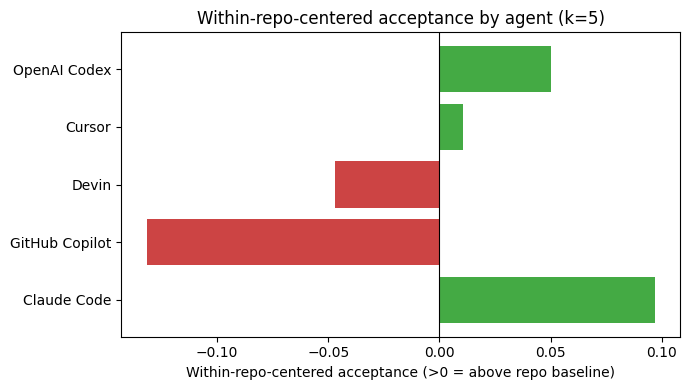


================ k = 10 ================
Mean within-repo-centered acceptance by agent (n = #repos):
                  mean  count
agent                        
Cursor          0.0423     10
OpenAI Codex    0.0139     13
Devin          -0.0146     11
GitHub Copilot -0.1480      3

Paired Wilcoxon on per-repo acceptance (only pairs with >=6 shared repos are tested):
     agent_a        agent_b  n_repos  median_diff_acc      p
OpenAI Codex         Cursor        7          -0.1222 0.0156
OpenAI Codex          Devin        7          -0.0367 0.9375
OpenAI Codex GitHub Copilot        2           0.3667    NaN
      Cursor          Devin        6           0.0075 0.8438
      Cursor GitHub Copilot        0              NaN    NaN
       Devin GitHub Copilot        1           0.1548    NaN


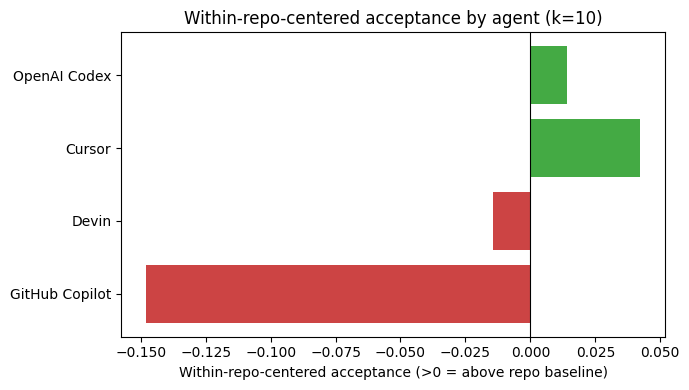

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

def agent_cat(s):
    """Categorical with Codex as reference (first), thin agents last."""
    cats = [a for a in AGENT_ORDER if a in set(pd.Series(s).dropna())]
    return pd.Categorical(s, categories=cats)

def within_repo_centered(panel):
    ra = (panel.groupby(["repo_id", "agent"])
                .agg(n=("id", "size"), acc_rate=("is_merged", "mean"),
                     med_merge_h=("merge_time_h", "median")).reset_index())
    ra["acc_rate_centered"] = ra["acc_rate"] - ra.groupby("repo_id")["acc_rate"].transform("mean")
    return ra

def paired_acc_tests(ra):
    wide = ra.pivot_table(index="repo_id", columns="agent", values="acc_rate")
    rows = []
    for a, b in combinations([c for c in AGENT_ORDER if c in wide.columns], 2):
        sub = wide[[a, b]].dropna()
        p = np.nan
        if len(sub) >= 6:
            try: _, p = wilcoxon(sub[a], sub[b])
            except ValueError: p = np.nan
        rows.append({"agent_a": a, "agent_b": b, "n_repos": len(sub),
                     "median_diff_acc": (sub[a] - sub[b]).median() if len(sub) else np.nan, "p": p})
    return pd.DataFrame(rows)

def fig_centered_acc(ra, K):
    g = ra.groupby("agent")["acc_rate_centered"].mean().reindex(
        [a for a in AGENT_ORDER if a in ra["agent"].unique()])
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#cc4444" if v < 0 else "#44aa44" for v in g.values]
    ax.barh(g.index[::-1], g.values[::-1], color=colors[::-1])
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("Within-repo-centered acceptance (>0 = above repo baseline)")
    ax.set_title(f"Within-repo-centered acceptance by agent (k={K})")
    fig.tight_layout(); fig.savefig(FIG / f"acceptance_centered_k{K}.png", dpi=150); plt.show(); plt.close(fig)

RA = {}
for K, (panel, qual) in PANELS.items():
    ra = within_repo_centered(panel); RA[K] = ra
    print(f"\n================ k = {K} ================")
    print("Mean within-repo-centered acceptance by agent (n = #repos):")
    print(ra.groupby("agent")["acc_rate_centered"].agg(["mean", "count"]).sort_values("mean", ascending=False).round(4))
    print("\nPaired Wilcoxon on per-repo acceptance (only pairs with >=6 shared repos are tested):")
    print(paired_acc_tests(ra).round(4).to_string(index=False))
    fig_centered_acc(ra, K)


## 5. Part A — within-repo estimators (models)

`merged ~ C(agent)` with **repo fixed effects** `C(repo_id)` is the within-repo estimator:
the repo dummies absorb each repo's baseline, so the agent coefficients are the within-repo
effect. (Random intercepts via `BinomialBayesMixedGLM` are the alternative for many repos.)

Run each model **twice** — once raw, once adjusted for task type + size — and report the gap.
That gap is how much of an agent's apparent edge is really task-mix (Section 6), not the agent.
Merge speed is right-censored, so use a **Cox model stratified by repo** (open / closed-unmerged
PRs are censored).


In [6]:
import statsmodels.formula.api as smf

def fe_logit(panel):
    """Within-repo (repo fixed-effects) acceptance logit, RAW vs task+size-ADJUSTED.
    Both fit by MLE on the SAME estimable agent set so the raw->adjusted gap is
    comparable. Agents that perfectly separate the FE model (too few repos) are
    dropped iteratively, least-supported first; Codex (reference) is always kept."""
    m = panel[panel["decided"]].dropna(subset=["agent", "repo_id"]).copy()
    m["repo_id"] = m["repo_id"].astype(str)
    m["is_merged"] = m["is_merged"].astype(int)
    all_ag = [a for a in AGENT_ORDER if a in set(m["agent"])]

    def fit_on(agents_keep, adjusted):
        d = m[m["agent"].isin(agents_keep)].copy()
        d["agent"] = pd.Categorical(d["agent"], categories=[a for a in AGENT_ORDER if a in agents_keep])
        f = "is_merged ~ C(agent) + C(repo_id)"
        if adjusted:
            f += " + C(task_type) + log_loc + files_touched"
            d = d.dropna(subset=["task_type", "log_loc", "files_touched"])
        return smf.logit(f, data=d).fit(disp=0, maxiter=300), len(d)

    def ok(fit):
        se = fit.bse.filter(like="C(agent)")
        return len(se) > 0 and np.isfinite(se).all() and (se < 5).all()

    support = m.groupby("agent")["repo_id"].nunique().sort_values()
    estimable, dropped = list(all_ag), []
    while len(estimable) >= 2:
        try:
            fr, _ = fit_on(estimable, False)
            if ok(fr): break
            raise np.linalg.LinAlgError("separation")
        except Exception:
            drop = next((a for a in support.index if a in estimable and a != "OpenAI Codex"), None)
            if drop is None: break
            estimable.remove(drop); dropped.append(drop)

    fit_raw, n_raw = fit_on(estimable, False)
    fit_adj, n_adj = fit_on(estimable, True)
    def terms(fit):
        s = fit.params.filter(like="C(agent)")
        return pd.DataFrame({"odds_ratio": np.exp(s), "coef": s,
                             "se": fit.bse.filter(like="C(agent)"),
                             "p": fit.pvalues.filter(like="C(agent)")})
    return terms(fit_raw), terms(fit_adj), dropped, n_raw, n_adj

LOGIT = {}
for K, (panel, qual) in PANELS.items():
    raw, adj, dropped, n_raw, n_adj = fe_logit(panel)
    LOGIT[K] = {"raw": raw, "adj": adj, "dropped": dropped}
    print(f"\n================ k = {K} (ref = OpenAI Codex) ================")
    if dropped:
        print(f"Excluded from logit (perfect separation, too few repos): {dropped}")
    print(f"RAW within-repo acceptance (n_decided={n_raw}):")
    print(raw.round(4).to_string())
    print(f"ADJUSTED for task type + size (n={n_adj}):")
    print(adj.round(4).to_string())
    gap = (adj["odds_ratio"] - raw["odds_ratio"]).round(3)
    print("RAW->ADJUSTED odds-ratio shift (how much task-mix/size explains):")
    print(gap.to_string())


C:\Users\luket\OneDrive\Documentos\GitHub\SENG404\groupproject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\luket\OneDrive\Documentos\GitHub\SENG404\groupproject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\luket\OneDrive\Documentos\GitHub\SENG404\groupproject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



================ k = 5 (ref = OpenAI Codex) ================
Excluded from logit (perfect separation, too few repos): ['Claude Code']
RAW within-repo acceptance (n_decided=2313):
                            odds_ratio    coef      se       p
C(agent)[T.Cursor]              1.9163  0.6504  0.1878  0.0005
C(agent)[T.Devin]               0.7200 -0.3286  0.1650  0.0464
C(agent)[T.GitHub Copilot]      0.2871 -1.2480  0.3604  0.0005
ADJUSTED for task type + size (n=2310):
                            odds_ratio    coef      se       p
C(agent)[T.Cursor]              2.0148  0.7005  0.1916  0.0003
C(agent)[T.Devin]               0.7815 -0.2466  0.1707  0.1487
C(agent)[T.GitHub Copilot]      0.2506 -1.3840  0.3756  0.0002
RAW->ADJUSTED odds-ratio shift (how much task-mix/size explains):
C(agent)[T.Cursor]            0.099
C(agent)[T.Devin]             0.062
C(agent)[T.GitHub Copilot]   -0.037

================ k = 10 (ref = OpenAI Codex) ================
RAW within-repo acceptance (n_decided=1

C:\Users\luket\OneDrive\Documentos\GitHub\SENG404\groupproject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
from lifelines import CoxPHFitter

def cox_merge_speed(panel):
    """Cox PH for time-to-merge, stratified by repo (within-repo baseline hazards).
    event = merged; open and closed-unmerged PRs are right-censored (NOT dropped).
    HR > 1 on an agent => merges FASTER than the reference (OpenAI Codex).
    Small penalizer stabilizes estimation with many strata / thin agents."""
    s = panel.copy()
    end = s["merged_at"].fillna(s["closed_at"])
    s["dur_h"] = (end - s["created_at"]).dt.total_seconds() / 3600
    s["event"] = s["is_merged"].astype(int)
    s = s[s["dur_h"] > 0].dropna(subset=["dur_h", "agent", "log_loc"])
    n_cens = int((s["event"] == 0).sum())
    cox = s[["dur_h", "event", "agent", "repo_id", "log_loc"]].copy()
    cox["agent"] = cox["agent"].astype(str)
    cox = pd.get_dummies(cox, columns=["agent"], drop_first=False)
    ref = "agent_OpenAI Codex"
    if ref in cox.columns:
        cox = cox.drop(columns=[ref])
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(cox, duration_col="dur_h", event_col="event", strata=["repo_id"])
    summ = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
    summ = summ.rename(columns={"exp(coef)": "HR"})
    return summ, len(cox), n_cens

COX = {}
for K, (panel, qual) in PANELS.items():
    summ, n, n_cens = cox_merge_speed(panel)
    COX[K] = summ
    print(f"\n================ k = {K} (ref = OpenAI Codex; HR>1 = faster) ================")
    print(f"N = {n} PRs, of which {n_cens} right-censored (open / closed-unmerged, kept)")
    print(summ.round(4).to_string())



================ k = 5 (ref = OpenAI Codex; HR>1 = faster) ================
N = 2338 PRs, of which 721 right-censored (open / closed-unmerged, kept)
                          HR  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                     
log_loc               0.8678               0.8492               0.8869  0.0000
agent_Claude Code     0.9655               0.6144               1.5171  0.8789
agent_Cursor          1.4464               1.2343               1.6948  0.0000
agent_Devin           0.7786               0.6700               0.9048  0.0011
agent_GitHub Copilot  0.9437               0.6911               1.2887  0.7154

================ k = 10 (ref = OpenAI Codex; HR>1 = faster) ================
N = 1385 PRs, of which 472 right-censored (open / closed-unmerged, kept)
                          HR  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                          

## 6. Part B — task-type specialization

Do agents occupy different task niches *within the same repo*? For each (repo, agent) compare
its task-type distribution to the repo-wide distribution using Jensen–Shannon divergence —
high JSD = that agent is specialized in that repo. Average to summarize.



================ k = 5 ================
Mean task-specialization (JSD vs repo baseline; higher = more specialized):
                  mean  count
agent                        
Claude Code     0.3808      4
Cursor          0.2857     21
GitHub Copilot  0.2636     10
OpenAI Codex    0.2498     30
Devin           0.2323     17

Agent x task share (row-normalized):
task_type       build  chore     ci   docs   feat    fix  other   perf  refactor  revert  style   test
agent                                                                                                 
Claude Code     0.000  0.000  0.000  0.160  0.480  0.200  0.000  0.000     0.120   0.000  0.000  0.040
Cursor          0.007  0.030  0.021  0.128  0.378  0.326  0.007  0.011     0.064   0.000  0.018  0.009
Devin           0.007  0.029  0.008  0.047  0.540  0.229  0.000  0.010     0.104   0.002  0.003  0.020
GitHub Copilot  0.031  0.021  0.062  0.062  0.313  0.436  0.010  0.010     0.041   0.000  0.005  0.010
OpenAI Codex    0

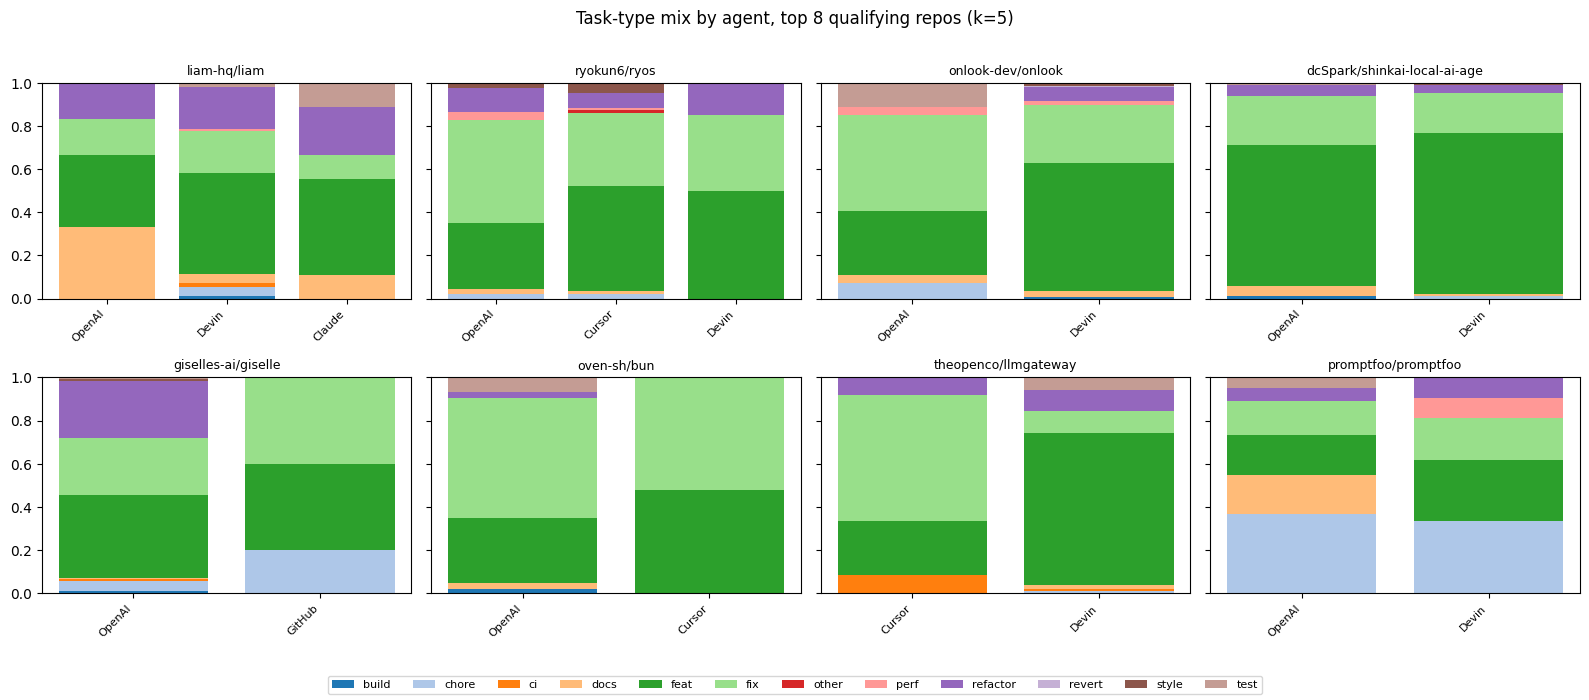


================ k = 10 ================
Mean task-specialization (JSD vs repo baseline; higher = more specialized):
                  mean  count
agent                        
GitHub Copilot  0.3221      3
Cursor          0.2563     10
OpenAI Codex    0.2223     13
Devin           0.2141     11

Agent x task share (row-normalized):
task_type       build  chore     ci   docs   feat    fix  other   perf  refactor  revert  style   test
agent                                                                                                 
Cursor          0.006  0.018  0.015  0.139  0.377  0.334  0.006  0.009     0.069   0.000  0.024  0.003
Devin           0.002  0.025  0.004  0.020  0.608  0.247  0.000  0.011     0.059   0.002  0.004  0.020
GitHub Copilot  0.023  0.000  0.116  0.047  0.442  0.256  0.047  0.023     0.047   0.000  0.000  0.000
OpenAI Codex    0.010  0.082  0.000  0.075  0.352  0.346  0.000  0.008     0.076   0.000  0.006  0.046


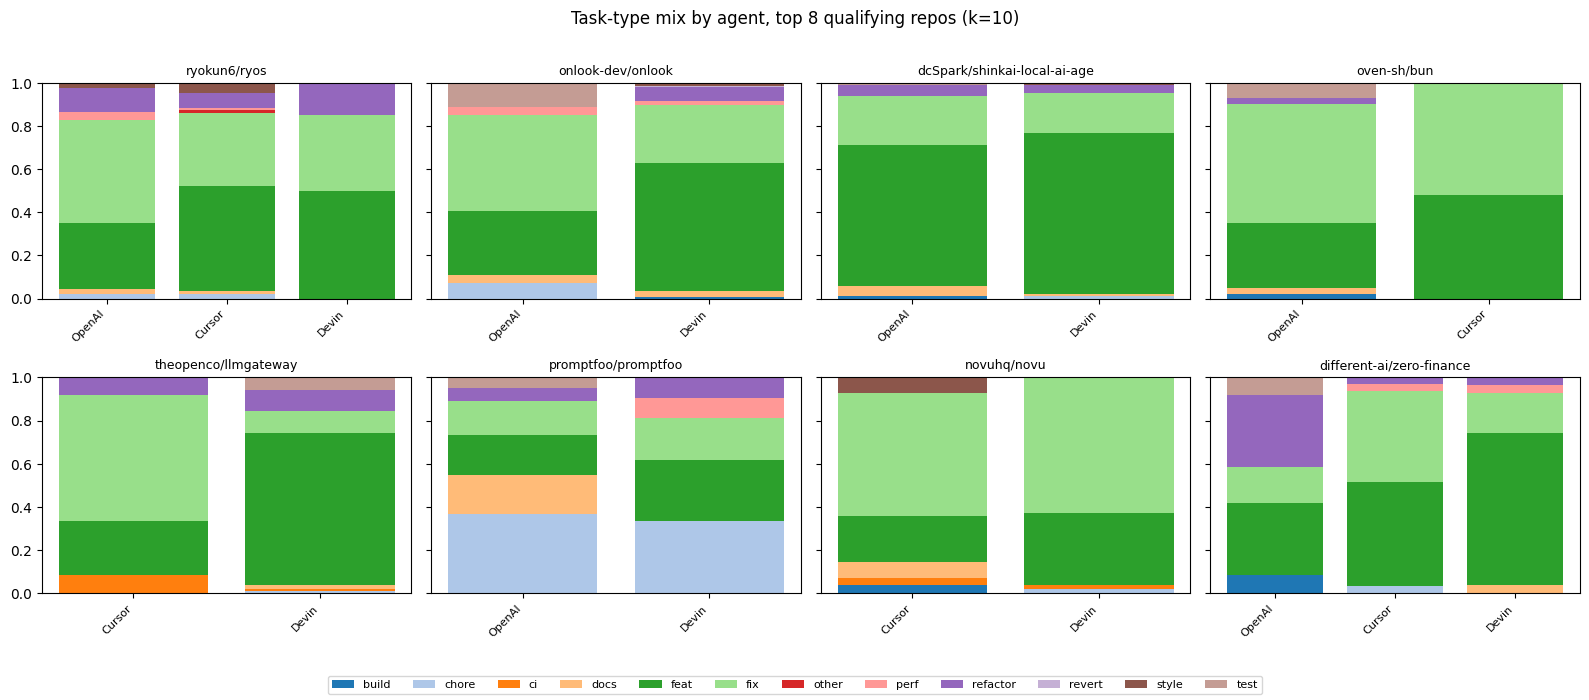

In [8]:
from scipy.spatial.distance import jensenshannon

def task_specialization(panel, K):
    TASKS = sorted(panel["task_type"].dropna().unique())
    def dist(sub):
        v = sub["task_type"].value_counts().reindex(TASKS).fillna(0).values.astype(float)
        s = v.sum()
        return v / s if s else v
    rows = []
    for rid, repo_df in panel.dropna(subset=["task_type"]).groupby("repo_id"):
        rd = dist(repo_df)
        for ag, ag_df in repo_df.groupby("agent"):
            rows.append({"repo_id": rid, "agent": ag, "n": len(ag_df),
                         "jsd": jensenshannon(dist(ag_df), rd, base=2)})
    spec = pd.DataFrame(rows)
    jsd = spec.groupby("agent")["jsd"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    share = pd.crosstab(panel["agent"], panel["task_type"], normalize="index").round(3)
    return jsd, share

def fig_task_mix(panel, K, topn=8):
    top = panel.groupby("repo_id").size().sort_values(ascending=False).head(topn).index
    sub = panel[panel["repo_id"].isin(top)]
    full = repos.set_index("id")["full_name"]
    tasks = sorted(panel["task_type"].dropna().unique())
    cmap = plt.get_cmap("tab20")
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
    for ax, rid in zip(axes.ravel(), top):
        ct = (pd.crosstab(sub[sub["repo_id"] == rid]["agent"], sub[sub["repo_id"] == rid]["task_type"],
                          normalize="index").reindex(columns=tasks).fillna(0))
        ct = ct.reindex([a for a in AGENT_ORDER if a in ct.index])
        bottom = np.zeros(len(ct))
        for i, t in enumerate(tasks):
            ax.bar(range(len(ct)), ct[t].values, bottom=bottom, color=cmap(i % 20), label=t)
            bottom += ct[t].values
        ax.set_xticks(range(len(ct))); ax.set_xticklabels([a.split()[0] for a in ct.index], rotation=45, ha="right", fontsize=8)
        ax.set_title(str(full.get(rid, rid))[:28], fontsize=9)
    for ax in axes.ravel()[len(top):]: ax.axis("off")
    h, l = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=len(tasks), fontsize=8)
    fig.suptitle(f"Task-type mix by agent, top {topn} qualifying repos (k={K})")
    fig.tight_layout(rect=[0, 0.06, 1, 0.97]); fig.savefig(FIG / f"task_mix_k{K}.png", dpi=150); plt.show(); plt.close(fig)

JSD = {}
for K, (panel, qual) in PANELS.items():
    jsd, share = task_specialization(panel, K); JSD[K] = jsd
    print(f"\n================ k = {K} ================")
    print("Mean task-specialization (JSD vs repo baseline; higher = more specialized):")
    print(jsd.round(4).to_string())
    print("\nAgent x task share (row-normalized):")
    print(share.to_string())
    fig_task_mix(panel, K)


## 7. Part B — size specialization

Is one agent the "small-change" agent and another the "big-change" agent *within the same
repos*? Model `log_loc ~ C(agent) + C(repo_id)`; Kruskal–Wallis per repo is a non-parametric cross-check.



================ k = 5 (ref = OpenAI Codex) ================
Within-repo size effect (coef on log LOC vs reference; + = larger PRs):
                            coef_log_loc       p
C(agent)[T.Cursor]                0.7213  0.0000
C(agent)[T.Devin]                 0.8752  0.0000
C(agent)[T.GitHub Copilot]       -0.2985  0.3161
C(agent)[T.Claude Code]           1.7570  0.0002

Median raw LOC changed by agent:
agent
OpenAI Codex       57.0
GitHub Copilot     74.0
Devin             150.5
Cursor            161.5
Claude Code       620.0

Repos with significant within-repo size differences across agents (Kruskal-Wallis p<.05): 12/37


C:\Users\luket\AppData\Local\Temp\claude\ipykernel_20160\1298157797.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=True, labels=[a.split()[0] for a in order], showfliers=False)


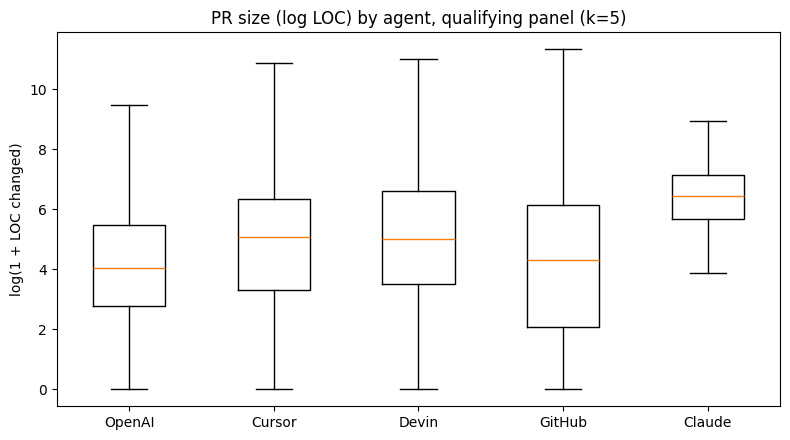


================ k = 10 (ref = OpenAI Codex) ================
Within-repo size effect (coef on log LOC vs reference; + = larger PRs):
                            coef_log_loc       p
C(agent)[T.Cursor]                0.6650  0.0002
C(agent)[T.Devin]                 0.7426  0.0000
C(agent)[T.GitHub Copilot]       -0.1665  0.7171

Median raw LOC changed by agent:
agent
OpenAI Codex       60.5
GitHub Copilot    132.0
Cursor            167.0
Devin             168.5

Repos with significant within-repo size differences across agents (Kruskal-Wallis p<.05): 7/17


C:\Users\luket\AppData\Local\Temp\claude\ipykernel_20160\1298157797.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=True, labels=[a.split()[0] for a in order], showfliers=False)


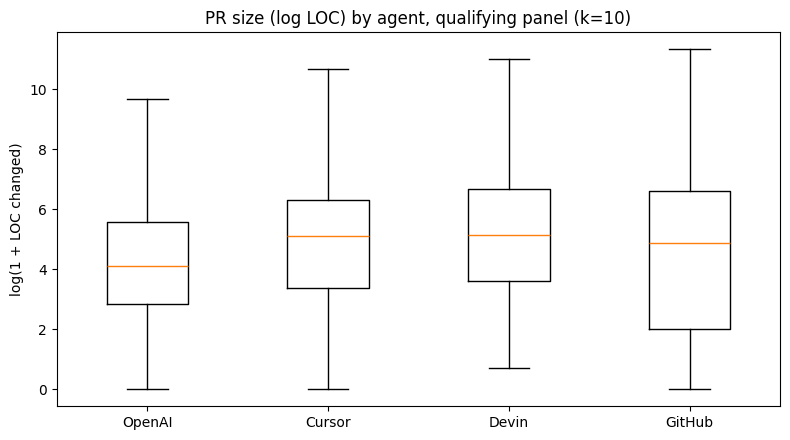

In [9]:
from scipy.stats import kruskal

def size_specialization(panel, K):
    sm = panel.dropna(subset=["log_loc", "agent"]).copy()
    sm["repo_id"] = sm["repo_id"].astype(str)
    sm["agent"] = agent_cat(sm["agent"])
    fit = smf.ols("log_loc ~ C(agent) + C(repo_id)", data=sm).fit()
    eff = pd.DataFrame({"coef_log_loc": fit.params.filter(like="C(agent)"),
                        "p": fit.pvalues.filter(like="C(agent)")})
    med = panel.groupby("agent")["loc"].median().sort_values()
    sig = tested = 0
    for rid, g in panel.dropna(subset=["loc"]).groupby("repo_id"):
        groups = [v["loc"].values for _, v in g.groupby("agent") if len(v) >= K]
        if len(groups) >= 2:
            tested += 1
            if kruskal(*groups).pvalue < 0.05: sig += 1
    return eff, med, sig, tested

def fig_loc_box(panel, K):
    order = [a for a in AGENT_ORDER if a in panel["agent"].unique()]
    data = [panel[panel["agent"] == a]["log_loc"].dropna().values for a in order]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.boxplot(data, vert=True, labels=[a.split()[0] for a in order], showfliers=False)
    ax.set_ylabel("log(1 + LOC changed)")
    ax.set_title(f"PR size (log LOC) by agent, qualifying panel (k={K})")
    fig.tight_layout(); fig.savefig(FIG / f"loc_box_k{K}.png", dpi=150); plt.show(); plt.close(fig)

SIZE = {}
for K, (panel, qual) in PANELS.items():
    eff, med, sig, tested = size_specialization(panel, K); SIZE[K] = eff
    print(f"\n================ k = {K} (ref = OpenAI Codex) ================")
    print("Within-repo size effect (coef on log LOC vs reference; + = larger PRs):")
    print(eff.round(4).to_string())
    print("\nMedian raw LOC changed by agent:")
    print(med.round(1).to_string())
    print(f"\nRepos with significant within-repo size differences across agents "
          f"(Kruskal-Wallis p<.05): {sig}/{tested}")
    fig_loc_box(panel, K)


## 8. Caveats & next steps (for the report)

- **A↔B confound.** Part B's signal is Part A's confounder: if a repo routes one agent to
  docs and another to features, the docs agent looks faster/more accepted for reasons of
  task mix, not quality. That's why Section 5 reports raw **and** task+size-adjusted effects —
  the gap is itself a finding.
- **Censoring.** Don't drop open PRs from speed analysis silently; the Cox model censors them.
- **Codex imbalance.** Codex dominates counts; report per-(repo,agent) N and lean on the
  within-repo design. This connects to the group's Q6 robustness checks.
- **Threshold sensitivity.** Re-run Section 3 at k=5 and k=10 and report whether conclusions hold.
- **Verify `pr_id == pull_request.id`** before trusting size features.
